In [1]:
import fastf1
import pandas as pd
import numpy as np
import requests
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor
import optuna

In [2]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows

In [3]:
# clean_air_race_pace = {
#     "VER": 90.413, "HAM": 92.153, "LEC": 91.580, "NOR": 89.787, "ALO": 92.502,
#     "PIA": 90.220, "RUS": 91.074, "STR": 92.324, "HUL": 92.528,
#     "OCO": 93.680, "ANT": 91.734
# }

In [4]:
qualifying_2026 = pd.DataFrame({
    "Driver": ["RUS", "ANT", "HAD", "LEC", "PIA", "NOR", "HAM", "LAW", "LIN", "BOR", "HUL", "BEA", "OCO", "GAS", "ALB", "COL", "ALO", "PER", "BOT", "VER", "SAI", "STR"],
    "QualifyingTime (s)": [
        78.518,     #RUS P1 POLE
        78.811,     #ANT P2 +0.293
        79.303,     #HAD P3 +0.293
        79.327,     #LEC P4 +0.293
        79.380,     #PIA P5 +0.293
        79.475,     #NOR P6 +0.293
        79.478,     #HAM P7 +0.293
        79.994,     #LAW P8 +0.293
        81.247,     #LIN P9 +0.293
        80.221,     #BOR P10 +0.293
        80.303,     #HUL P11 +0.293
        80.311,     #BEA P12 +0.293
        80.491,     #OCO P13 +0.293
        80.501,     #GAS P14 +0.293
        80.941,     #ALB P15 +0.293
        81.270,     #COL P16 +0.293
        81.969,     #ALO P17 +0.293
        82.605,     #PER P18 +0.293
        83.244,     #BOT P19 +0.293
        82.500,     #VER P20 +0.293
        83.000,     #SAI P21 +0.293
        85.000,     #STR P22 +0.293
    ],
    "GridPosition": list(range(1, 23))
})

In [5]:
qualifying_2026

,Driver,QualifyingTime (s),GridPosition
0,RUS,78.518,1
1,ANT,78.811,2
2,HAD,79.303,3
3,LEC,79.327,4
4,PIA,79.380,5
5,NOR,79.475,6
6,HAM,79.478,7
7,LAW,79.994,8
8,LIN,81.247,9
9,BOR,80.221,10


In [6]:
# qualifying_2026["CleanAirRacePace (s)"] = qualifying_2026["Driver"].map(clean_air_race_pace)
API_KEY = "1bff7bc4fa854db41d7d87d55b6aa82a"
lat, lon = -37.849694, 144.968000
weather_url = f"http://api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
response = requests.get(weather_url)
weather_data = response.json()

forecast_time = "2026-03-08 13:00:00"
forecast_data = next((f for f in weather_data["list"] if f["dt_txt"] == forecast_time), None)

In [7]:
forecast_data

In [8]:
rain_probability = forecast_data["pop"] if forecast_data else 0
temperature = forecast_data["main"]["temp"] if forecast_data else 20

In [9]:
rain_probability

0

In [10]:
temperature

20

In [11]:
if rain_probability >= 0.75:
    qualifying_2026["QualifyingTime"] = qualifying_2026["QualifyingTime (s)"] * qualifying_2026["WetPerformanceFactor"]
else:
    qualifying_2026["QualifyingTime"] = qualifying_2026["QualifyingTime (s)"]

In [12]:
team_points_2025 = {
    "McLaren": 800, "Mercedes": 450, "Red Bull": 426, "Williams": 137, "Ferrari": 382, "Cadillac": 5,
    "Haas": 73, "Aston Martin": 80, "Kick Sauber": 0, "Racing Bulls": 92, "Alpine": 22, "Audi": 68
}

In [13]:
max_points = max(team_points_2025.values())
team_performance_score = {team: points / max_points for team, points in team_points_2025.items()}

In [14]:
driver_to_team = {
    "RUS": "Mercedes", "ANT": "Mercedes",
    "VER": "Red Bull", "HAD": "Red Bull",
    "LEC": "Ferrari", "HAM": "Ferrari",
    "NOR": "McLaren", "PIA": "McLaren",
    "ALB": "Williams", "SAI": "Williams",
    "ALO": "Aston Martin", "STR": "Aston Martin",
    "BEA": "Haas", "OCO": "Haas",
    "LAW": "Racing Bulls", "LIN": "Racing Bulls",
    "HUL": "Audi", "BOR": "Audi",
    "GAS": "Alpine", "COL": "Alpine",
    "PER": "Cadillac", "BOT": "Cadillac"
}

In [15]:
qualifying_2026["Team"] = qualifying_2026["Driver"].map(driver_to_team)
qualifying_2026["TeamPerformanceScore"] = qualifying_2026["Team"].map(team_performance_score)

In [16]:
reg_change_boost = {
    "Mercedes": 1.15,
    "Ferrari": 1.05,
    "Red Bull": 0.95,
    "McLaren": 1.00,
    "Williams": 0.80,
    "Aston Martin": 0.70,
    "Haas": 0.85,
    "Racing Bulls": 0.88,
    "Audi": 0.83,
    "Alpine": 0.80,
    "Cadillac": 0.70
}

In [17]:
qualifying_2026["RegChangeBoost"] = qualifying_2026["Team"].map(reg_change_boost)
qualifying_2026["AdjustedTeamScore"] = (
        qualifying_2026["TeamPerformanceScore"] * qualifying_2026["RegChangeBoost"])

In [18]:
qualifying_2026

,Driver,QualifyingTime (s),GridPosition,QualifyingTime,Team,TeamPerformanceScore,RegChangeBoost,AdjustedTeamScore
0,RUS,78.518,1,78.518,Mercedes,0.56250,1.15,0.646875
1,ANT,78.811,2,78.811,Mercedes,0.56250,1.15,0.646875
2,HAD,79.303,3,79.303,Red Bull,0.53250,0.95,0.505875
3,LEC,79.327,4,79.327,Ferrari,0.47750,1.05,0.501375
4,PIA,79.380,5,79.380,McLaren,1.00000,1.00,1.000000
5,NOR,79.475,6,79.475,McLaren,1.00000,1.00,1.000000
6,HAM,79.478,7,79.478,Ferrari,0.47750,1.05,0.501375
7,LAW,79.994,8,79.994,Racing Bulls,0.11500,0.88,0.101200
8,LIN,81.247,9,81.247,Racing Bulls,0.11500,0.88,0.101200
9,BOR,80.221,10,80.221,Audi,0.08500,0.83,0.070550


In [19]:
merged_data = []
qualifying_2026["RainProbability"] = rain_probability
qualifying_2026["Temperature"] = temperature
qualifying_2026["GridPenalty (s)"] = (qualifying_2026["GridPosition"] - 1) * 0.15
pole_time = qualifying_2026["QualifyingTime (s)"].min()
qualifying_2026["GapFromPole (s)"] = qualifying_2026["QualifyingTime (s)"] - pole_time
merged_data = qualifying_2026.copy()

In [20]:
merged_data

,Driver,QualifyingTime (s),GridPosition,QualifyingTime,Team,TeamPerformanceScore,RegChangeBoost,AdjustedTeamScore,RainProbability,Temperature,GridPenalty (s),GapFromPole (s)
0,RUS,78.518,1,78.518,Mercedes,0.56250,1.15,0.646875,0,20,0.00,0.000
1,ANT,78.811,2,78.811,Mercedes,0.56250,1.15,0.646875,0,20,0.15,0.293
2,HAD,79.303,3,79.303,Red Bull,0.53250,0.95,0.505875,0,20,0.30,0.785
3,LEC,79.327,4,79.327,Ferrari,0.47750,1.05,0.501375,0,20,0.45,0.809
4,PIA,79.380,5,79.380,McLaren,1.00000,1.00,1.000000,0,20,0.60,0.862
5,NOR,79.475,6,79.475,McLaren,1.00000,1.00,1.000000,0,20,0.75,0.957
6,HAM,79.478,7,79.478,Ferrari,0.47750,1.05,0.501375,0,20,0.90,0.960
7,LAW,79.994,8,79.994,Racing Bulls,0.11500,0.88,0.101200,0,20,1.05,1.476
8,LIN,81.247,9,81.247,Racing Bulls,0.11500,0.88,0.101200,0,20,1.20,2.729
9,BOR,80.221,10,80.221,Audi,0.08500,0.83,0.070550,0,20,1.35,1.703


In [21]:
QUALI_TO_RACE_FACTOR = 1.055
merged_data["TargetLapTime (s)"] = merged_data["QualifyingTime (s)"] * QUALI_TO_RACE_FACTOR

In [22]:
merged_data

,Driver,QualifyingTime (s),GridPosition,QualifyingTime,Team,TeamPerformanceScore,RegChangeBoost,AdjustedTeamScore,RainProbability,Temperature,GridPenalty (s),GapFromPole (s),TargetLapTime (s)
0,RUS,78.518,1,78.518,Mercedes,0.56250,1.15,0.646875,0,20,0.00,0.000,82.836490
1,ANT,78.811,2,78.811,Mercedes,0.56250,1.15,0.646875,0,20,0.15,0.293,83.145605
2,HAD,79.303,3,79.303,Red Bull,0.53250,0.95,0.505875,0,20,0.30,0.785,83.664665
3,LEC,79.327,4,79.327,Ferrari,0.47750,1.05,0.501375,0,20,0.45,0.809,83.689985
4,PIA,79.380,5,79.380,McLaren,1.00000,1.00,1.000000,0,20,0.60,0.862,83.745900
5,NOR,79.475,6,79.475,McLaren,1.00000,1.00,1.000000,0,20,0.75,0.957,83.846125
6,HAM,79.478,7,79.478,Ferrari,0.47750,1.05,0.501375,0,20,0.90,0.960,83.849290
7,LAW,79.994,8,79.994,Racing Bulls,0.11500,0.88,0.101200,0,20,1.05,1.476,84.393670
8,LIN,81.247,9,81.247,Racing Bulls,0.11500,0.88,0.101200,0,20,1.20,2.729,85.715585
9,BOR,80.221,10,80.221,Audi,0.08500,0.83,0.070550,0,20,1.35,1.703,84.633155


In [23]:
X = merged_data[[
    "QualifyingTime (s)", "GapFromPole (s)", "AdjustedTeamScore", "GridPenalty (s)", "RainProbability", "Temperature"
]]
y = merged_data["TargetLapTime (s)"].copy()

In [24]:
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [25]:
QUALI_SCALE = 3.0
X_scaled = X_imputed.copy()
X_scaled[ : , 0] *= QUALI_SCALE
X_scaled[ : , 1] *= QUALI_SCALE

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=39)

In [27]:
model = XGBRegressor(n_estimators=350, learning_rate=0.8, max_depth=5, random_state=39,  monotone_constraints='(1, 0, 0, -1, -1)')
model.fit(X_train, y_train)
merged_data["PredictedRaceTime (s)"] = model.predict(X_imputed)

In [27]:
MONOTONE_CONSTRAINTS = "(1, 1, -1, 1, 1, 0)"

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "random_state": 39,
        "objective": "reg:squarederror",
        "monotone_constraints": MONOTONE_CONSTRAINTS,
        "tree_method": "hist"
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set= [(X_test, y_test)], verbose= False)
    # merged_data["PredictedRaceTime (s)"] = model.predict(X_scaled)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)

    return mae


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best MAE:", study.best_value)
print("Best parameters:")
print(study.best_params)

[I 2026-03-14 17:02:39,749] A new study created in memory with name: no-name-b8da7076-8273-49bc-98db-ef1cdc482801


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-14 17:02:40,039] Trial 0 finished with value: 1.403072097656252 and parameters: {'n_estimators': 770, 'learning_rate': 0.012664317169130362, 'max_depth': 4, 'subsample': 0.5316507641603483, 'colsample_bytree': 0.8608147477617335, 'reg_lambda': 0.004277011746046655, 'max_delta_step': 6, 'min_child_weight': 13.903035741922759, 'gamma': 2.4981666934231206}. Best is trial 0 with value: 1.403072097656252.
[I 2026-03-14 17:02:40,247] Trial 1 finished with value: 0.5148936005859355 and parameters: {'n_estimators': 761, 'learning_rate': 0.13952336273389981, 'max_depth': 5, 'subsample': 0.6323789958791458, 'colsample_bytree': 0.8351606015221269, 'reg_lambda': 0.0053448483495261104, 'max_delta_step': 7, 'min_child_weight': 4.933414838161484, 'gamma': 1.999771275376605}. Best is trial 1 with value: 0.5148936005859355.
[I 2026-03-14 17:02:40,440] Trial 2 finished with value: 0.4468312529296895 and parameters: {'n_estimators': 692, 'learning_rate': 0.030820686680379503, 'max_depth': 4, '

In [28]:
best_params = study.best_params.copy()
best_params.update({
    "random_state": 39,
    "objective": "reg:squarederror",
    "monotone_constraints": MONOTONE_CONSTRAINTS,
    "tree_method": "hist"
})

best_model = XGBRegressor(**best_params)

best_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

merged_data["PredictedRaceTime (s)"] = best_model.predict(X_scaled)

In [29]:
merged_data

,Driver,QualifyingTime (s),GridPosition,QualifyingTime,Team,TeamPerformanceScore,RegChangeBoost,AdjustedTeamScore,RainProbability,Temperature,GridPenalty (s),GapFromPole (s),TargetLapTime (s),PredictedRaceTime (s)
0,RUS,78.518,1,78.518,Mercedes,0.56250,1.15,0.646875,0,20,0.00,0.000,82.836490,83.654564
1,ANT,78.811,2,78.811,Mercedes,0.56250,1.15,0.646875,0,20,0.15,0.293,83.145605,83.654564
2,HAD,79.303,3,79.303,Red Bull,0.53250,0.95,0.505875,0,20,0.30,0.785,83.664665,83.654564
3,LEC,79.327,4,79.327,Ferrari,0.47750,1.05,0.501375,0,20,0.45,0.809,83.689985,83.791542
4,PIA,79.380,5,79.380,McLaren,1.00000,1.00,1.000000,0,20,0.60,0.862,83.745900,83.923065
5,NOR,79.475,6,79.475,McLaren,1.00000,1.00,1.000000,0,20,0.75,0.957,83.846125,83.923065
6,HAM,79.478,7,79.478,Ferrari,0.47750,1.05,0.501375,0,20,0.90,0.960,83.849290,84.086571
7,LAW,79.994,8,79.994,Racing Bulls,0.11500,0.88,0.101200,0,20,1.05,1.476,84.393670,84.086571
8,LIN,81.247,9,81.247,Racing Bulls,0.11500,0.88,0.101200,0,20,1.20,2.729,85.715585,85.766022
9,BOR,80.221,10,80.221,Audi,0.08500,0.83,0.070550,0,20,1.35,1.703,84.633155,84.462082


In [30]:
test_mae = mean_absolute_error(y_test, best_model.predict(X_test))
print("Best params:", study.best_params)
print("MAE from Optuna:", study.best_value)

Best params: {'n_estimators': 712, 'learning_rate': 0.10314086178101399, 'max_depth': 10, 'subsample': 0.5763240310596965, 'colsample_bytree': 0.834929870937788, 'reg_lambda': 0.008032665651100312, 'max_delta_step': 6, 'min_child_weight': 1.0102013407815174, 'gamma': 2.525956324003281}
MAE from Optuna: 0.1009223627929714


In [31]:
final_results = merged_data.sort_values(by=["PredictedRaceTime (s)", "GridPosition"]).reset_index(drop=True)
print(final_results[["Driver", "PredictedRaceTime (s)"]])

   Driver  PredictedRaceTime (s)
0     RUS              83.654564
1     ANT              83.654564
2     HAD              83.654564
3     LEC              83.791542
4     PIA              83.923065
5     NOR              83.923065
6     HAM              84.086571
7     LAW              84.086571
8     BOR              84.462082
9     HUL              84.462082
10    BEA              84.462082
11    OCO              84.606415
12    GAS              84.915970
13    ALB              85.032249
14    LIN              85.766022
15    COL              86.551971
16    ALO              86.551971
17    PER              87.112480
18    VER              87.112480
19    SAI              87.757431
20    BOT              87.957512
21    STR              87.957512


In [32]:
podium = final_results.loc[:7, ["Driver", "PredictedRaceTime (s)"]]
print("\n🏆 Predicted in the Top 3 🏆")
print(f"🥇 P1: {podium.iloc[0]['Driver']}")
print(f"🥈 P2: {podium.iloc[1]['Driver']}")
print(f"🥉 P3: {podium.iloc[2]['Driver']}")
print(f"Model Error (MAE): {mean_absolute_error(y_test, best_model.predict(X_test)):.2f} seconds")


🏆 Predicted in the Top 3 🏆
🥇 P1: RUS
🥈 P2: ANT
🥉 P3: HAD
Model Error (MAE): 0.10 seconds


In [33]:
feature_importance = best_model.feature_importances_
features = X.columns

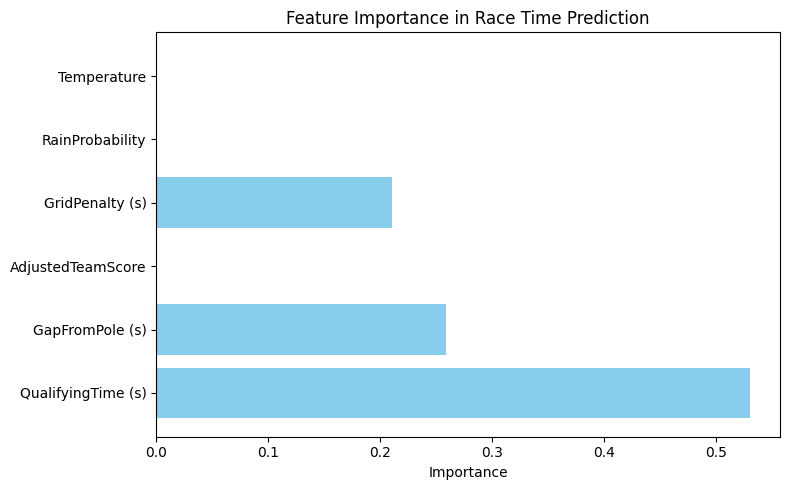

In [34]:
plt.figure(figsize=(8,5))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance in Race Time Prediction")
plt.tight_layout()
plt.show()